Code to merge the brightfield (ref.dv) file with channel 2 (erm-1) for line scan analysis

In [5]:
#import packages:
import os
import matplotlib.pyplot as plt
import numpy as np

import tifffile
import bigfish
import bigfish.stack as stack
import bigfish.plot as plot
import bigfish.multistack as multistack
import bigfish.detection as detection


In [6]:
# #Parameters if running as jupyter notebook

folder_name = '/Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_01' #your folder should contain 2 images (.dv and its ref.dv)

# User-defined channel names (set to None if the channel does not exist)
Cy5 = "set-3_mRNA"  # (Q670)
mCherry = "lin-41_mRNA"  # (Q610)
FITC = "pgranules"  # (GFP)
DAPI = "DAPI"
brightfield = "brightfield"


In [10]:
#check image dimensions

# Reading the microscopy data
current_directory = os.getcwd()
folder_path = os.path.join(current_directory, folder_name)

if os.path.exists(folder_path):
    # List the files in the folder
    list_filenames = os.listdir(folder_path)
    list_filenames = sorted(list_filenames)
    path_files = [os.path.join(folder_path, filename) for filename in list_filenames if not filename.startswith('.ipynb_checkpoints')]

    # Read DV files and store image stacks in list_images
    list_images = []
    for image in path_files:
        image_stack = stack.read_dv(image)
        list_images.append(image_stack)

# Extract Image ID by removing the "_R3D_REF.dv" suffix
dv_filename = list_filenames[1]
if dv_filename.endswith("_R3D_REF.dv"):
    image_name = dv_filename[:-len("_R3D_REF.dv")]
else:
    image_name = dv_filename  # In case the suffix is different, just keep the original name
print(f'Image ID: {image_name}', '\n')

# Converting the image to a specific shape
bf = list_images[1] # [C,Z,Y,X]
image_colors = list_images[0] # Reference [Y,X]

bf = bf.astype(np.uint16)
image_colors = image_colors.astype(np.uint16)

# print(f'Image files: {list_filenames}', '\n')
print(f'Image colors \n{list_filenames[0]}: {image_colors.shape} \n')
print(f'Brightfield \n{list_filenames[1]}: {bf.shape}')
# print(f'Image_colors: {image_colors.shape}')


ValueError: /Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_01/.DS_Store is not a recognized DV file.

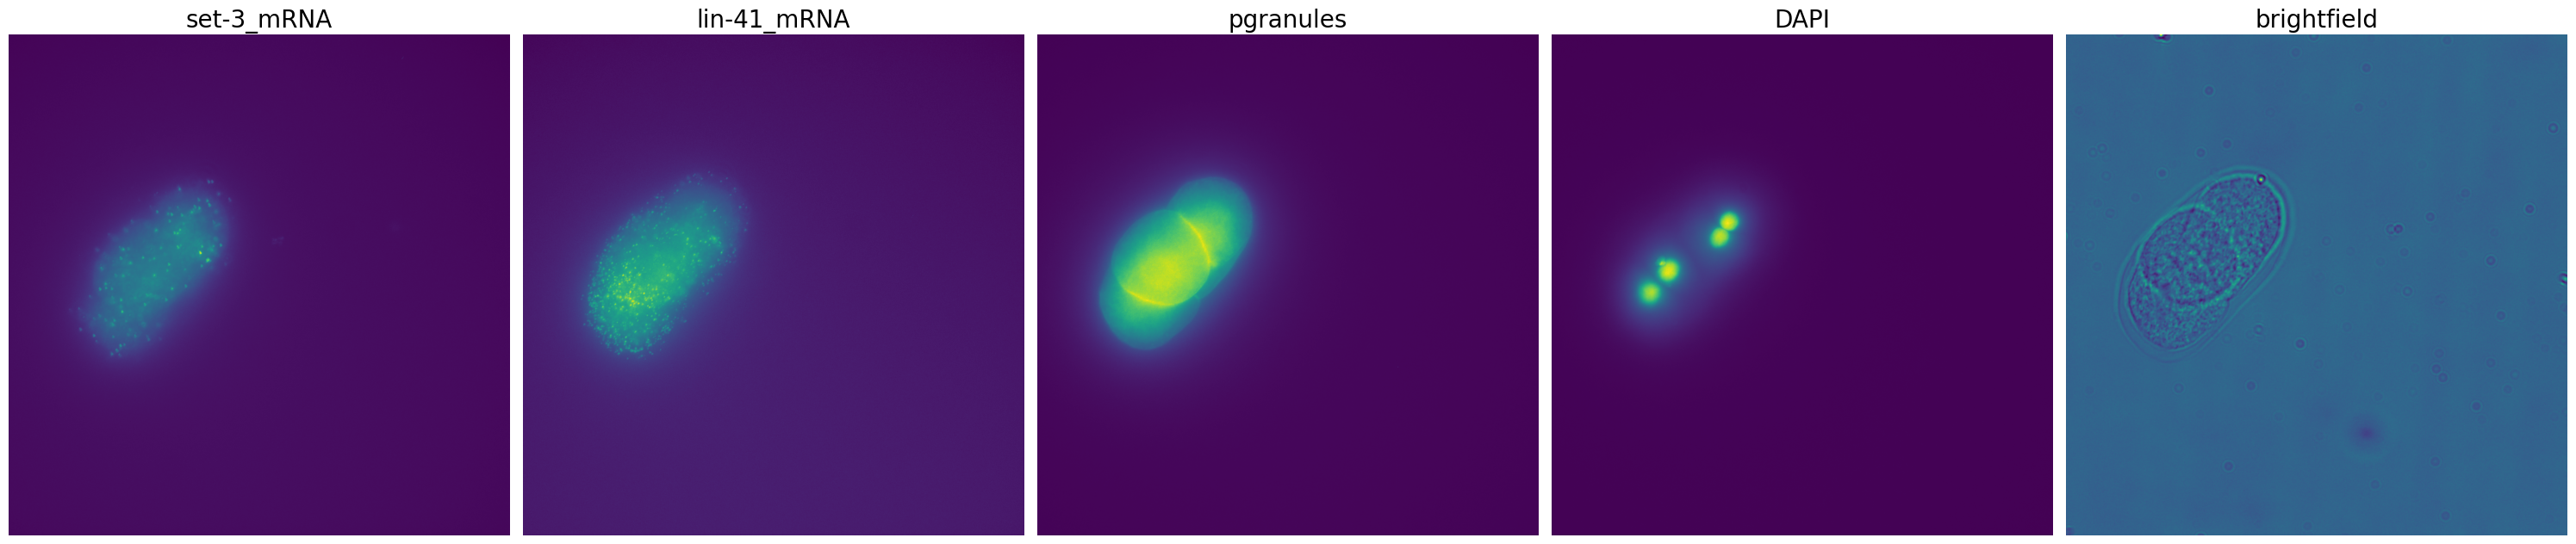

In [43]:
# List of channel names and their corresponding images

# Create output folder if it doesn't exist
output_directory = folder_name + "_results"
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

channels = [Cy5, mCherry, FITC, DAPI, brightfield]
titles = [Cy5, mCherry, FITC, DAPI, brightfield]
images = [
    np.max(image_colors[0, :, :, :], axis=0) if image_colors[0] is not None and Cy5 else None,
    np.max(image_colors[1, :, :, :], axis=0) if image_colors[1] is not None and mCherry else None,
    np.max(image_colors[2, :, :, :], axis=0) if image_colors[2] is not None and FITC else None,
    np.max(image_colors[3, :, :, :], axis=0) if image_colors[3] is not None and DAPI else None,
    bf if brightfield is not None else None
]

# Filter out None entries
filtered_images = [(img, title) for img, title in zip(images, titles) if img is not None]

fig, ax = plt.subplots(1, len(filtered_images), figsize=(6 * len(filtered_images), 8))

# Ensure ax is always iterable, even if there's only one plot
if len(filtered_images) == 1:
    ax = [ax]

for i, (img, title) in enumerate(filtered_images):
    ax[i].imshow(img)
    ax[i].set_title(title, size=20)
    ax[i].axis('off')

# Adjust layout if necessary
plt.tight_layout()

# Save the plots in the results folder
plt.savefig(os.path.join(output_directory, 'colors_' + image_name + '.png'))

plt.show()

In [11]:
# index channel 2 and merge with bf

# Channel 2 = mCh
mCh = np.max(image_colors[1, :, :, :], axis=0)


# Normalize images
bf_norm = bf.astype(float)
bf_norm = (bf_norm - bf_norm.min()) / (bf_norm.max() - bf_norm.min())

mCh_norm = mCh.astype(float)
mCh_norm = (mCh_norm - mCh_norm.min()) / (mCh_norm.max() - mCh_norm.min())

# Create RGB composite
composite = np.zeros((*bf_norm.shape, 3))

# Brightfield in grayscale
composite[:, :, 0] = bf_norm
composite[:, :, 1] = bf_norm
composite[:, :, 2] = bf_norm

# Add mCh signal in green
composite[:, :, 1] = np.maximum(composite[:, :, 1], mCh_norm)

# Display
plt.figure(figsize=(8, 8))
plt.imshow(composite)
plt.axis('off')
plt.title(f'{mCherry} + Brightfield', size=20)
plt.tight_layout()

# Save
plt.savefig(
    os.path.join(output_directory, 'mCh_BF_composite_' + image_name + '.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

NameError: name 'image_colors' is not defined

Found 3 subdirectories.

Processing: test_files_01
Image colors 230713_Lp306_L4440_01_R3D.dv: (4, 66, 1024, 1024)
Brightfield 230713_Lp306_L4440_01_R3D_REF.dv: (1024, 1024)
Image ID: 230713_Lp306_L4440_01


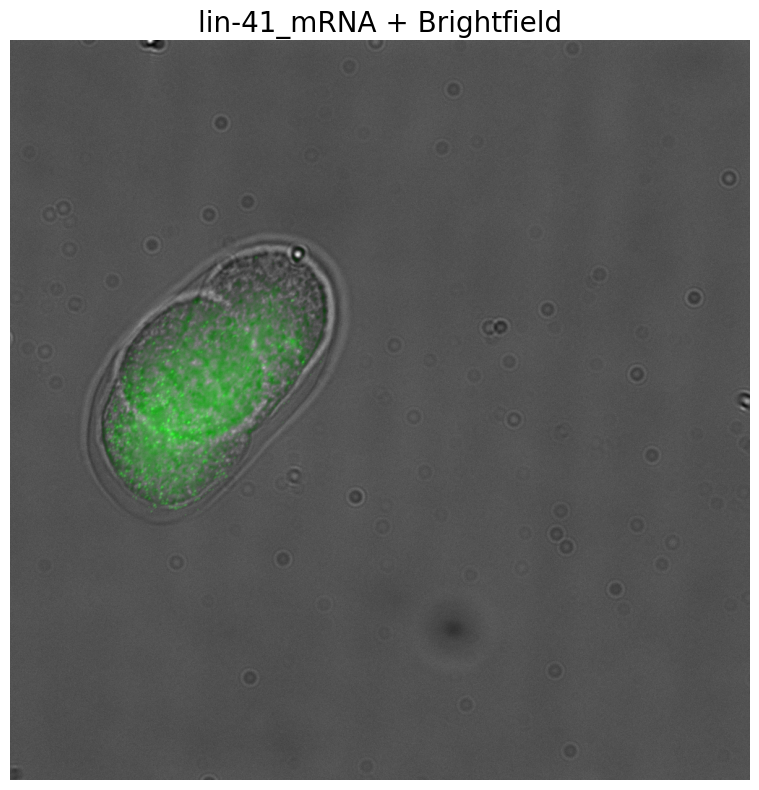

Saved raw TIFF: /Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_01/results/lin-41_mRNA_BF_raw_230713_Lp306_L4440_01.tiff

Processing: test_files_02
Image colors 230713_Lp306_L4440_02_R3D.dv: (4, 66, 1024, 1024)
Brightfield 230713_Lp306_L4440_02_R3D_REF.dv: (1024, 1024)
Image ID: 230713_Lp306_L4440_02


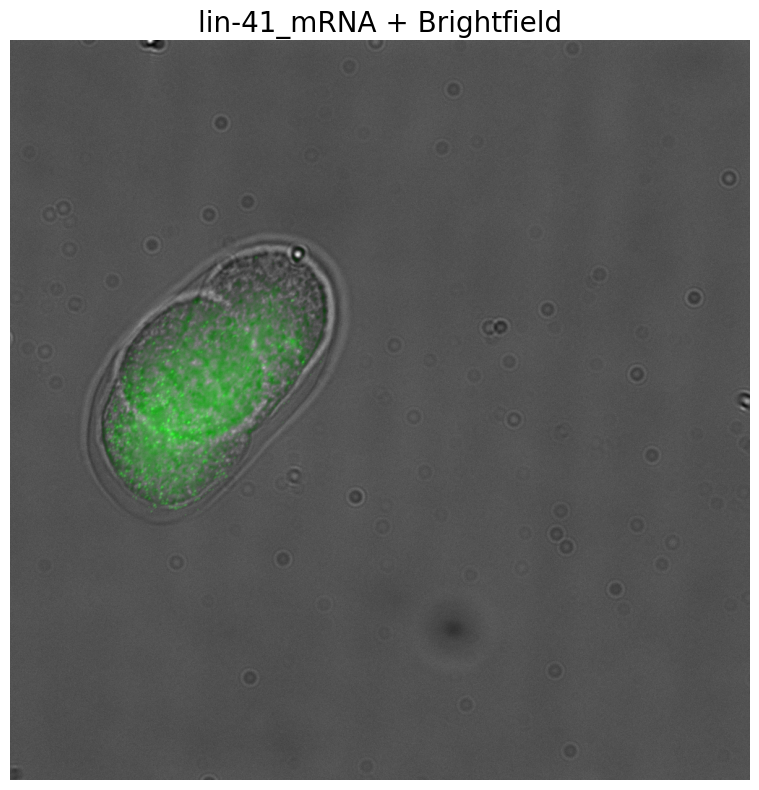

Saved raw TIFF: /Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_02/results/lin-41_mRNA_BF_raw_230713_Lp306_L4440_02.tiff

Processing: test_files_03
Image colors 230713_Lp306_L4440_03_R3D.dv: (4, 66, 1024, 1024)
Brightfield 230713_Lp306_L4440_03_R3D_REF.dv: (1024, 1024)
Image ID: 230713_Lp306_L4440_03


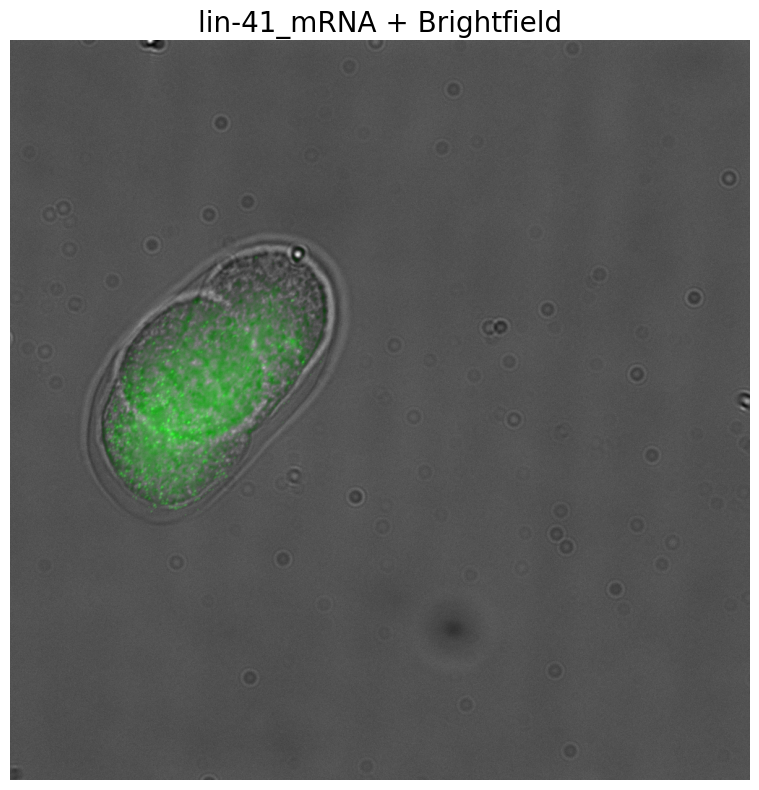

Saved raw TIFF: /Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_03/results/lin-41_mRNA_BF_raw_230713_Lp306_L4440_03.tiff


In [12]:
# ============================================================
# Parameters
# ============================================================

folder_name = '/Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files'

# User-defined channel names
Cy5 = "set-3_mRNA"
mCherry = "lin-41_mRNA"
FITC = "pgranules"
DAPI = "DAPI"
brightfield = "brightfield"


# ============================================================
# Find subdirectories
# ============================================================

subdirectories = sorted([
    d for d in os.listdir(folder_name)
    if os.path.isdir(os.path.join(folder_name, d))
])

print(f"Found {len(subdirectories)} subdirectories.")


# ============================================================
# Process each image folder
# ============================================================

for subdir in subdirectories:

    print(f"\nProcessing: {subdir}")

    # Folder containing the two DV files
    folder_path = os.path.join(folder_name, subdir)

    # --------------------------------------------------------
    # Find DV files
    # --------------------------------------------------------

    list_filenames = sorted([
        filename for filename in os.listdir(folder_path)
        if filename.endswith(".dv")
        and not filename.startswith(".")
    ])

    if len(list_filenames) != 2:
        print(
            f"Skipping {subdir}: "
            f"expected 2 DV files, found {len(list_filenames)}"
        )
        continue

    # --------------------------------------------------------
    # Read DV files
    # --------------------------------------------------------

    list_images = []

    for image in list_filenames:

        image_path = os.path.join(
            folder_path,
            image
        )

        image_stack = stack.read_dv(image_path)

        list_images.append(image_stack)

    # --------------------------------------------------------
    # Assign images
    # --------------------------------------------------------

    image_colors = list_images[0]
    bf = list_images[1]

    image_colors = image_colors.astype(np.uint16)
    bf = bf.astype(np.uint16)

    print(
        f'Image colors '
        f'{list_filenames[0]}: {image_colors.shape}'
    )

    print(
        f'Brightfield '
        f'{list_filenames[1]}: {bf.shape}'
    )

    # --------------------------------------------------------
    # Extract Image ID
    # --------------------------------------------------------

    dv_filename = list_filenames[1]

    if dv_filename.endswith("_R3D_REF.dv"):
        image_name = dv_filename[
            :-len("_R3D_REF.dv")
        ]
    else:
        image_name = os.path.splitext(
            dv_filename
        )[0]

    print(f'Image ID: {image_name}')


    # ========================================================
    # Create output folder
    # ========================================================

    output_directory = os.path.join(
        folder_path,
        "results"
    )

    os.makedirs(
        output_directory,
        exist_ok=True
    )


    # ========================================================
    # INDEX CHANNEL 1 / mCherry
    # ========================================================

    # image_colors = (4, 66, 1024, 1024)
    #
    # Position 1 = Python index 1
    #
    # Maximum projection across Z

    mCh = np.max(
        image_colors[1, :, :, :],
        axis=0
    )


    # ========================================================
    # NORMALIZE FOR DISPLAY
    # ========================================================

    bf_norm = bf.astype(float)

    bf_norm = (
        (bf_norm - bf_norm.min()) /
        (bf_norm.max() - bf_norm.min())
    )

    mCh_norm = mCh.astype(float)

    mCh_norm = (
        (mCh_norm - mCh_norm.min()) /
        (mCh_norm.max() - mCh_norm.min())
    )


    # ========================================================
    # CREATE RGB COMPOSITE
    # ========================================================

    composite = np.zeros(
        (*bf_norm.shape, 3)
    )

    # Brightfield in grayscale
    composite[:, :, 0] = bf_norm
    composite[:, :, 1] = bf_norm
    composite[:, :, 2] = bf_norm

    # mCherry signal in green
    composite[:, :, 1] = np.maximum(
        composite[:, :, 1],
        mCh_norm
    )


    # ========================================================
    # DISPLAY + SAVE PNG
    # ========================================================

    plt.figure(figsize=(8, 8))

    plt.imshow(composite)
    plt.axis('off')

    plt.title(
        f'{mCherry} + Brightfield',
        size=20
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_directory,
            'mCh_BF_composite_' + image_name + '.png'
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


    # ========================================================
    # SAVE RAW INTENSITIES AS TIFF
    # ========================================================

    mCh_raw = np.max(
        image_colors[1, :, :, :],
        axis=0
    )

    mCh_raw = mCh_raw.astype(np.uint16)
    bf_raw = bf.astype(np.uint16)

    raw_stack = np.stack(
        [mCh_raw, bf_raw],
        axis=0
    )

    output_file = os.path.join(
        output_directory,
        f'{mCherry}_BF_raw_{image_name}.tiff'
    )

    tifffile.imwrite(
        output_file,
        raw_stack
    )

    print(f"Saved raw TIFF: {output_file}")

In [53]:
import tifffile
import os
import numpy as np

# Channel 2 (position 3)
mCh_raw = np.max(image_colors[1, :, :, :], axis=0)

# Make sure both are uint16
mCh_raw = mCh_raw.astype(np.uint16)
bf_raw = bf.astype(np.uint16)

# Save the two raw channels together as a multi-channel TIFF
output_file = os.path.join(
    output_directory,
    f'{mCherry}_BF_raw_{image_name}.tiff'
)

raw_stack = np.stack([mCh_raw, bf_raw], axis=0)

tifffile.imwrite(
    output_file,
    raw_stack
)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_01_results/lin-41_mRNA_BF_raw_230713_Lp306_L4440_03_R3D.tiff'

In [54]:
## Run in batch

# Parent directory
folder_name = "/Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files"

# Find subdirectories
subdirectories = sorted([
    d for d in os.listdir(folder_name)
    if os.path.isdir(os.path.join(folder_name, d))
])

print(f"Found {len(subdirectories)} subdirectories.")

for subdir in subdirectories:

    subdir_path = os.path.join(folder_name, subdir)

    print(f"\nProcessing: {subdir}")

    # Find DV files
    list_filenames = sorted([
        f for f in os.listdir(subdir_path)
        if f.lower().endswith(".dv")
        and not f.startswith(".")
    ])

    if len(list_filenames) != 2:
        print(f"Skipping {subdir}: found {len(list_filenames)} DV files.")
        continue

    # --------------------------------------------------
    # Read the two files
    # --------------------------------------------------

    list_images = []

    for filename in list_filenames:

        filepath = os.path.join(subdir_path, filename)

        image_stack = stack.read_dv(filepath)

        list_images.append(image_stack)

    # --------------------------------------------------
    # Assign images
    # --------------------------------------------------

    image_colors = list_images[0]   # (4, 66, 1024, 1024)
    bf = list_images[1]             # (1024, 1024)

    image_colors = image_colors.astype(np.uint16)
    bf = bf.astype(np.uint16)

    print(f"image_colors: {image_colors.shape}")
    print(f"bf: {bf.shape}")

    # --------------------------------------------------
    # Extract position 1
    # --------------------------------------------------

    mCh_raw = np.max(
        image_colors[1, :, :, :],
        axis=0
    ).astype(np.uint16)

    bf_raw = bf.astype(np.uint16)

    print(f"mCh_raw: {mCh_raw.shape}")
    print(f"bf_raw: {bf_raw.shape}")

    # --------------------------------------------------
    # Check dimensions
    # --------------------------------------------------

    if mCh_raw.shape != bf_raw.shape:
        print(
            f"Skipping {subdir}: dimensions don't match "
            f"{mCh_raw.shape} vs {bf_raw.shape}"
        )
        continue

    # --------------------------------------------------
    # Combine raw images
    # --------------------------------------------------

    raw_stack = np.stack(
        [mCh_raw, bf_raw],
        axis=0
    )

    # --------------------------------------------------
    # Create results folder
    # --------------------------------------------------

    output_directory = os.path.join(
        subdir_path,
        "results"
    )

    os.makedirs(
        output_directory,
        exist_ok=True
    )

    # --------------------------------------------------
    # Output filename
    # --------------------------------------------------

    image_name = os.path.splitext(list_filenames[0])[0]

    output_file = os.path.join(
        output_directory,
        f"{image_name}_pos1_BF_raw.tiff"
    )

    # --------------------------------------------------
    # Save
    # --------------------------------------------------

    tifffile.imwrite(
        output_file,
        raw_stack
    )

    print(f"Saved: {output_file}")

Found 3 subdirectories.

Processing: test_files_01
image_colors: (4, 66, 1024, 1024)
bf: (1024, 1024)
mCh_raw: (1024, 1024)
bf_raw: (1024, 1024)
Saved: /Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_01/results/230713_Lp306_L4440_01_R3D_pos1_BF_raw.tiff

Processing: test_files_02
image_colors: (4, 66, 1024, 1024)
bf: (1024, 1024)
mCh_raw: (1024, 1024)
bf_raw: (1024, 1024)
Saved: /Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_02/results/230713_Lp306_L4440_02_R3D_pos1_BF_raw.tiff

Processing: test_files_03
image_colors: (4, 66, 1024, 1024)
bf: (1024, 1024)
mCh_raw: (1024, 1024)
bf_raw: (1024, 1024)
Saved: /Users/nalytorres/Library/CloudStorage/OneDrive-Colostate/01_EON_Lab/01_PUBLICATION/erm-1_paper/test_files/test_files_03/results/230713_Lp306_L4440_03_R3D_pos1_BF_raw.tiff
